# Zajęcie 3: Liniowe RNN

<u> https://peterroelants.github.io/posts/rnn-implementation-part01/#Linear-recurrent-neural-network </u>

<b>Celem</b> jest implementowanie od podstaw rekurencyjnych sieci neuronowych (RNN) w języku Python i NumPy. 

Pokażemy, jak zaimplementować minimalną RNN. RNN jest wystarczająco prosta, aby zwizualizować powierzchnię strat i zbadać, dlaczego podczas optymalizacji mogą wystąpić zanikające i eksplodujące gradienty. Aby zapewnić stabilność, RNN zostanie przeszkolony z propagacją wsteczną w czasie przy użyciu algorytmu optymalizacji RProp.

$$S_k = f(S_{k-1}\cdot W_{rec} + X_k \cdot W_x)$$

In [ ]:
%matplotlib inline
%config InlineBackend.figure_formats = ['svg']


import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import LogNorm
import seaborn as sns

sns.set_style('darkgrid')
np.random.seed(seed=1)

## Tworzenie zbioru danych
Dane wejściowe użyte w tym przykładzie składają się z 20 sekwencji binarnych po 10 kroków czasowych każda. Każda sekwencja wejściowa jest generowana z jednolitego rozkładu losowego, który jest zaokrąglany do 0 lub 1.

Cele wyjściowe `t` to liczba wystąpień „1” w sekwencji, która jest równa sumie tej sekwencji, ponieważ sekwencja jest binarna.

In [ ]:
nb_of_samples = 30
sequence_len = 20

possible_values = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

random_indices = np.random.randint(0, len(possible_values), size=(nb_of_samples, sequence_len))
X = possible_values[random_indices]

t = np.sum(X == 0.6, axis=1)

## Krok do przodu

In [ ]:
def update_state(xk, sk, wx, wRec):
    return xk * wx + sk * wRec

def forward_states(X, wx, wRec):
    S = np.zeros((X.shape[0], X.shape[1]+1))
    for k in range(0, X.shape[1]):
        S[:,k+1] = update_state(X[:,k], S[:,k], wx, wRec)
    return S

def loss(y, t): 
    return np.mean((t - y)**2)

## Krok wstecz

In [ ]:
def output_gradient(y, t):
    return 2. * (y - t)

def backward_gradient(X, S, grad_out, wRec):
    grad_over_time = np.zeros((X.shape[0], X.shape[1]+1))
    grad_over_time[:,-1] = grad_out
    wx_grad = 0
    wRec_grad = 0
    for k in range(X.shape[1], 0, -1):
        wx_grad += np.sum(
            np.mean(grad_over_time[:,k] * X[:,k-1], axis=0))
        wRec_grad += np.sum(
            np.mean(grad_over_time[:,k] * S[:,k-1]), axis=0)
        grad_over_time[:,k-1] = grad_over_time[:,k] * wRec
    return (wx_grad, wRec_grad), grad_over_time

## Sprawdzanie gradienta

In [ ]:
params = [1.2, 1.2]
eps = 1e-7

S = forward_states(X, params[0], params[1])
grad_out = output_gradient(S[:,-1], t)
backprop_grads, grad_over_time = backward_gradient(
    X, S, grad_out, params[1])

for p_idx, _ in enumerate(params):
    grad_backprop = backprop_grads[p_idx]
    params[p_idx] += eps
    plus_loss = loss(forward_states(X, params[0], params[1])[:,-1], t)
    params[p_idx] -= 2 * eps
    min_loss = loss(forward_states(X, params[0], params[1])[:,-1], t)
    params[p_idx] += eps
    grad_num = (plus_loss - min_loss) / (2*eps)
    if not np.isclose(grad_num, grad_backprop):
        raise ValueError((
            f'Numerical gradient of {grad_num:.6f} is not close to '
            f'the backpropagation gradient of {grad_backprop:.6f}!'))
print('No gradient errors found')
#

No gradient errors found


## Wizualizacja

In [ ]:
points = [(2,1,'r'), (1,2,'b'), (1,-2,'m'), (1,0,'c'), 
          (1,0.5,'g'), (1,-0.5,'y')]


def get_loss_surface(w1_low, w1_high, w2_low, w2_high, 
                     nb_of_ws, loss_func):
    w1 = np.linspace(w1_low, w1_high, num=nb_of_ws)
    w2 = np.linspace(w2_low, w2_high, num=nb_of_ws)
    ws1, ws2 = np.meshgrid(w1, w2)
    loss_ws = np.zeros((nb_of_ws, nb_of_ws))
    for i in range(nb_of_ws):
        for j in range(nb_of_ws):
            loss_ws[i,j] = loss_func(ws1[i,j], ws2[i,j])
    return ws1, ws2, loss_ws


def plot_surface(ax, ws1, ws2, loss_ws):
    surf = ax.contourf(
        ws1, ws2, loss_ws, levels=np.logspace(-0.2, 8, 30), 
        cmap=cm.viridis, norm=LogNorm())
    ax.set_xlabel('$w_{in}$', fontsize=12)
    ax.set_ylabel('$w_{rec}$', fontsize=12)
    return surf


def plot_points(ax, points):
    for wx, wRec, c in points:
        ax.plot(wx, wRec, c+'o', linewidth=2)

        
def get_loss_surface_figure(loss_func, points):
    fig = plt.figure(figsize=(10, 4))   
    ax_1 = fig.add_subplot(1,2,1)
    ws1_1, ws2_1, loss_ws_1 = get_loss_surface(
        -3, 3, -3, 3, 50, loss_func)
    surf_1 = plot_surface(ax_1, ws1_1, ws2_1, loss_ws_1 + 1)
    plot_points(ax_1, points)
    ax_1.set_xlim(-3, 3)
    ax_1.set_ylim(-3, 3)
    ax_2 = fig.add_subplot(1,2,2)
    ws1_2, ws2_2, loss_ws_2 = get_loss_surface(
        -0.1, 2.1, -0.1, 2.1, 50, loss_func)
    surf_2 = plot_surface(ax_2, ws1_2, ws2_2, loss_ws_2 + 1)
    plot_points(ax_2, points)
    ax_2.set_xlim(-0.1, 2.1)
    ax_2.set_ylim(-0.1, 2.1)
    fig.subplots_adjust(right=0.8)
    cax = fig.add_axes([0.85, 0.12, 0.03, 0.78])
    cbar = fig.colorbar(
        surf_1, ticks=np.logspace(0, 8, 9), cax=cax)
    cbar.ax.set_ylabel(
        '$\\xi$', fontsize=12, rotation=0, labelpad=20)
    cbar.set_ticklabels(
        ['{:.0e}'.format(i) for i in np.logspace(0, 8, 9)])
    fig.suptitle('Loss surface', fontsize=15)
    return fig


def plot_gradient_over_time(points, get_grad_over_time):
    fig = plt.figure(figsize=(7, 3))
    ax = plt.subplot(111)
    for wx, wRec, c in points:
        grad_over_time = get_grad_over_time(wx, wRec)
        x = np.arange(-grad_over_time.shape[1]+1, 1, 1)
        plt.plot(
            x, np.sum(grad_over_time, axis=0), c+'-', 
            label=f'({wx}, {wRec})', linewidth=1, markersize=8)
    plt.xlim(0, -grad_over_time.shape[1]+1)
    plt.xticks(x)
    plt.yscale('symlog')
    plt.yticks([10**8, 10**6, 10**4, 10**2, 0, -10**2, -10**4, 
                -10**6, -10**8])
    plt.xlabel('timestep k', fontsize=12)
    plt.ylabel('$\\frac{\\partial \\xi}{\\partial S_{k}}$', 
               fontsize=20, rotation=0)
    plt.title(('Unstability of gradient in backward propagation.'
               '\n(backpropagate from left to right)'))
    leg = plt.legend(
        loc='center left', bbox_to_anchor=(1, 0.5), 
        frameon=False, numpoints=1)
    leg.set_title('$(w_x, w_{rec})$', prop={'size':15})
    fig.subplots_adjust(right=0.8)
    

def get_grad_over_time(wx, wRec):
    S = forward_states(X, wx, wRec)
    grad_out = output_gradient(S[:,-1], t).sum()
    _, grad_over_time = backward_gradient(X, S, grad_out, wRec)
    return grad_over_time
#

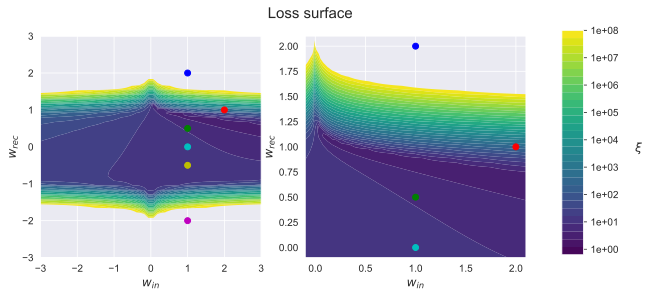

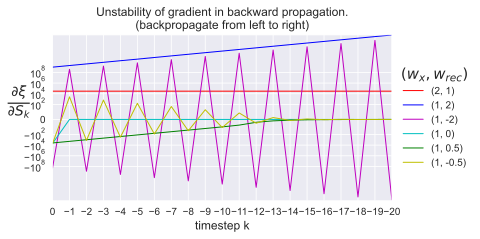

In [ ]:
fig = get_loss_surface_figure(
    lambda w1, w2: loss(forward_states(X, w1, w2)[:,-1] , t), points)

plot_gradient_over_time(points, get_grad_over_time)
plt.show()
#

# Optymizacja RProp 

In [ ]:
def update_rprop(X, t, W, W_prev_sign, W_delta, eta_p, eta_n):
    S = forward_states(X, W[0], W[1])
    grad_out = output_gradient(S[:,-1], t)
    W_grads, _ = backward_gradient(X, S, grad_out, W[1])
    W_sign = np.sign(W_grads)
    for i, _ in enumerate(W):
        if W_sign[i] == W_prev_sign[i]:
            W_delta[i] *= eta_p
        else:
            W_delta[i] *= eta_n
    return W_delta, W_sign

In [ ]:
eta_p = 1.2
eta_n = 0.5

W = [-1.5, 2]
W_delta = [0.001, 0.001]
W_sign = [0, 0]

ls_of_ws = [(W[0], W[1])]
for i in range(500):
    W_delta, W_sign = update_rprop(
        X, t, W, W_sign, W_delta, eta_p, eta_n)
    for i, _ in enumerate(W):
        W[i] -= W_sign[i] * W_delta[i]
    ls_of_ws.append((W[0], W[1]))

print(f'Final weights are: wx = {W[0]:.4f},  wRec = {W[1]:.4f}')

Final weights are: wx = 0.8813,  wRec = 0.8699


## Wykresy dla optymizacji

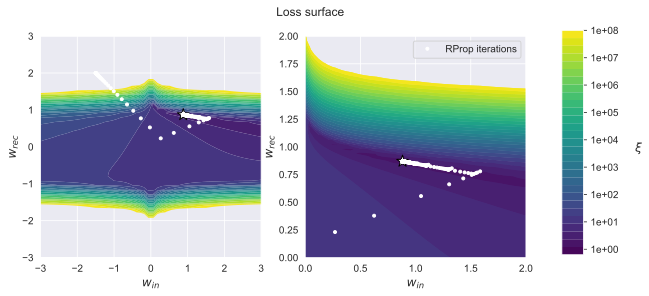

In [ ]:
def plot_optimisation(ls_of_ws, loss_func):
    ws1, ws2 = zip(*ls_of_ws)
    fig = plt.figure(figsize=(10, 4))
    ax_1 = fig.add_subplot(1, 2, 1)
    ws1_1, ws2_1, loss_ws_1 = get_loss_surface(
        -3, 3, -3, 3, 50, loss_func)
    surf_1 = plot_surface(ax_1, ws1_1, ws2_1, loss_ws_1 + 1)
    ax_1.plot(ws1, ws2, 'wo', markersize=3)
    ax_1.scatter(ws1[-1], ws2[-1], color='w', marker='*', s=150, edgecolors='k')
    ax_1.set_xlim([-3, 3])
    ax_1.set_ylim([-3, 3])
    ax_2 = fig.add_subplot(1, 2, 2)
    ws1_2, ws2_2, loss_ws_2 = get_loss_surface(
        0, 2, 0, 2, 50, loss_func)
    surf_2 = plot_surface(ax_2, ws1_2, ws2_2, loss_ws_2 + 1)
    ax_2.set_xlim([0, 2])
    ax_2.set_ylim([0, 2])
    surf_2 = plot_surface(ax_2, ws1_2, ws2_2, loss_ws_2)
    ax_2.plot(ws1, ws2, 'wo', 
              label='RProp iterations', markersize=3)
    ax_2.scatter(ws1[-1], ws2[-1], color='w', marker='*', s=150, edgecolors='k')
    ax_2.legend()
    fig.subplots_adjust(right=0.8)
    cax = fig.add_axes([0.85, 0.12, 0.03, 0.78])
    cbar = fig.colorbar(
        surf_1, ticks=np.logspace(0, 8, 9), cax=cax)
    cbar.ax.set_ylabel(
        '$\\xi$', fontsize=12, rotation=0, labelpad=20)
    cbar.set_ticklabels(
        ['{:.0e}'.format(i) for i in np.logspace(0, 8, 9)])
    plt.suptitle('Loss surface', fontsize=12)
    plt.show()
    
plot_optimisation(
    ls_of_ws, lambda w1, w2: loss(forward_states(X, w1, w2)[:,-1] , t))
plt.show()
#

# Ostateczny model

In [29]:
test_inpt = np.asmatrix([[0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1]])
test_outpt = forward_states(test_inpt, W[0], W[1])[:,-1]
sum_test_inpt = test_inpt.sum()
print((
    f'Target output: {sum_test_inpt:d} vs Model output: '
    f'{test_outpt[0]:.2f}'))
#

Target output: 5 vs Model output: 2.62


# Zadania

1. Dane wejściowe składają się z 30 sekwencji po 20 kroków czasowych każda. Każda sekwencja wejściowa jest generowana z jednolitego rozkładu losowego, który jest zaokrąglany do 0, 0.5 lub 1. Cele wyjściowe `t` to liczba wystąpień „0.5” w sekwencji.
2. Dane wejściowe składają się z 30 sekwencji po 20 kroków czasowych każda. Każda sekwencja wejściowa jest generowana z jednolitego rozkładu losowego, który jest zaokrąglany do 0.33, 0.66 lub 1. Cele wyjściowe `t` to liczba wystąpień „0.33” w sekwencji.
3. Dane wejściowe składają się z 30 sekwencji po 20 kroków czasowych każda. Każda sekwencja wejściowa jest generowana z jednolitego rozkładu losowego, który jest zaokrąglany do 0, 0.5 lub 1. Cele wyjściowe `t` to suma liczb w sekwencji.
4. Dane wejściowe składają się z 30 sekwencji po 20 kroków czasowych każda. Każda sekwencja wejściowa jest generowana z jednolitego rozkładu losowego, który jest zaokrąglany do 0.33, 0.66 lub 1. Cele wyjściowe `t` to suma liczb w sekwencji.
5. Dane wejściowe składają się z 30 sekwencji po 20 kroków czasowych każda. Każda sekwencja wejściowa jest generowana z jednolitego rozkładu losowego, który jest zaokrąglany do 0.33, 0.66 lub 1. Cele wyjściowe `t` to średnia wartość liczb w sekwencji.
6. Dane wejściowe składają się z 30 sekwencji po 20 kroków czasowych każda. Każda sekwencja wejściowa jest generowana z jednolitego rozkładu losowego, który jest zaokrąglany do 0.33, 0.66 lub 1. Cele wyjściowe `t` to średnie odchylenie wartości liczb w sekwencji.
7. Dane wejściowe składają się z 30 sekwencji po 20 kroków czasowych każda. Każda sekwencja wejściowa jest generowana z jednolitego rozkładu losowego, który jest zaokrąglany do 0, 0.2, 0.4, 0.6, 0.8 lub 1. Cele wyjściowe `t` to liczba wystąpień „0.6” w sekwencji.
8. Dane wejściowe składają się z 30 sekwencji po 20 kroków czasowych każda. Każda sekwencja wejściowa jest generowana z jednolitego rozkładu losowego, który jest zaokrąglany do 0, 0.2, 0.4, 0.6, 0.8 lub 1. Cele wyjściowe `t` to liczba wystąpień „0.4” w sekwencji.
9. Dane wejściowe składają się z 30 sekwencji po 20 kroków czasowych każda. Każda sekwencja wejściowa jest generowana z jednolitego rozkładu losowego, który jest zaokrąglany do 0, 0.2, 0.4, 0.6, 0.8 lub 1. Cele wyjściowe `t` to suma liczb w sekwencji.
10. Dane wejściowe składają się z 30 sekwencji po 20 kroków czasowych każda. Każda sekwencja wejściowa jest generowana z jednolitego rozkładu losowego, który jest zaokrąglany do 0, 0.2, 0.4, 0.6, 0.8 lub 1. Cele wyjściowe `t` to suma liczb w sekwencji.
11. Dane wejściowe składają się z 30 sekwencji po 20 kroków czasowych każda. Każda sekwencja wejściowa jest generowana z jednolitego rozkładu losowego, który jest zaokrąglany do 0, 0.2, 0.4, 0.6, 0.8 lub 1. Cele wyjściowe `t` to średnia wartość liczb w sekwencji.
12. Dane wejściowe składają się z 30 sekwencji po 20 kroków czasowych każda. Każda sekwencja wejściowa jest generowana z jednolitego rozkładu losowego, który jest zaokrąglany do 0, 0.2, 0.4, 0.6, 0.8 lub 1. Cele wyjściowe `t` to średnie odchylenie wartości liczb w sekwencji.